Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  67


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  15


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 8 blocks (MaxPool2D in each second block)

In [7]:
in_channels = 3
out_channels = 8
size = 64

model_blocks = []

for i in range(1, 9):
    conv = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
    batch_norm = nn.BatchNorm2d(out_channels)
    model_blocks.extend(
        [conv, batch_norm, nn.ReLU()]
    )
    if i%2==0:
        model_blocks.append(nn.MaxPool2d(2,2))
        size = size//2
    
    in_channels = out_channels
    out_channels = out_channels * 2

print(f"Final In Channels = {in_channels}")
print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final In Channels = 1024
Final Out Channels = 2048
Final Shape = 4


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(in_channels * size * size, in_channels),
    nn.ReLU(),
    nn.Linear(in_channels, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
    
    )

### Use Trainer to train and check validations

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment3/",
    save_checkpoints=1,
    print_every=10
    )

In [11]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.5195 | Val Loss: 0.7010 | Train Acc: 0.8034 | Val Acc: 0.7345 | Train F1: 0.8043 | Val F1: 0.7365
Epoch [20/100] | Train Loss: 0.2682 | Val Loss: 0.9082 | Train Acc: 0.9140 | Val Acc: 0.6350 | Train F1: 0.9147 | Val F1: 0.6304
Epoch [30/100] | Train Loss: 0.1243 | Val Loss: 4.4880 | Train Acc: 0.9820 | Val Acc: 0.3606 | Train F1: 0.9821 | Val F1: 0.2008
Epoch [40/100] | Train Loss: 0.0638 | Val Loss: 1.6856 | Train Acc: 0.9948 | Val Acc: 0.5885 | Train F1: 0.9948 | Val F1: 0.5515
Epoch [50/100] | Train Loss: 0.0264 | Val Loss: 0.6018 | Train Acc: 0.9981 | Val Acc: 0.8407 | Train F1: 0.9981 | Val F1: 0.8425
Epoch [60/100] | Train Loss: 0.0182 | Val Loss: 0.6103 | Train Acc: 0.9995 | Val Acc: 0.8473 | Train F1: 0.9995 | Val F1: 0.8487
Epoch [70/100] | Train Loss: 0.0113 | Val Loss: 0.6988 | Train Acc: 1.0000 | Val Acc: 0.8584 | Train F1: 1.0000 | Val F1: 0.8592
Epoch [80/100] | Train Loss: 0.0220 | Val Loss: 5.6315 | Train Acc: 0.9962 | Val Acc: 0.3606 | Tr

### Save Metrics

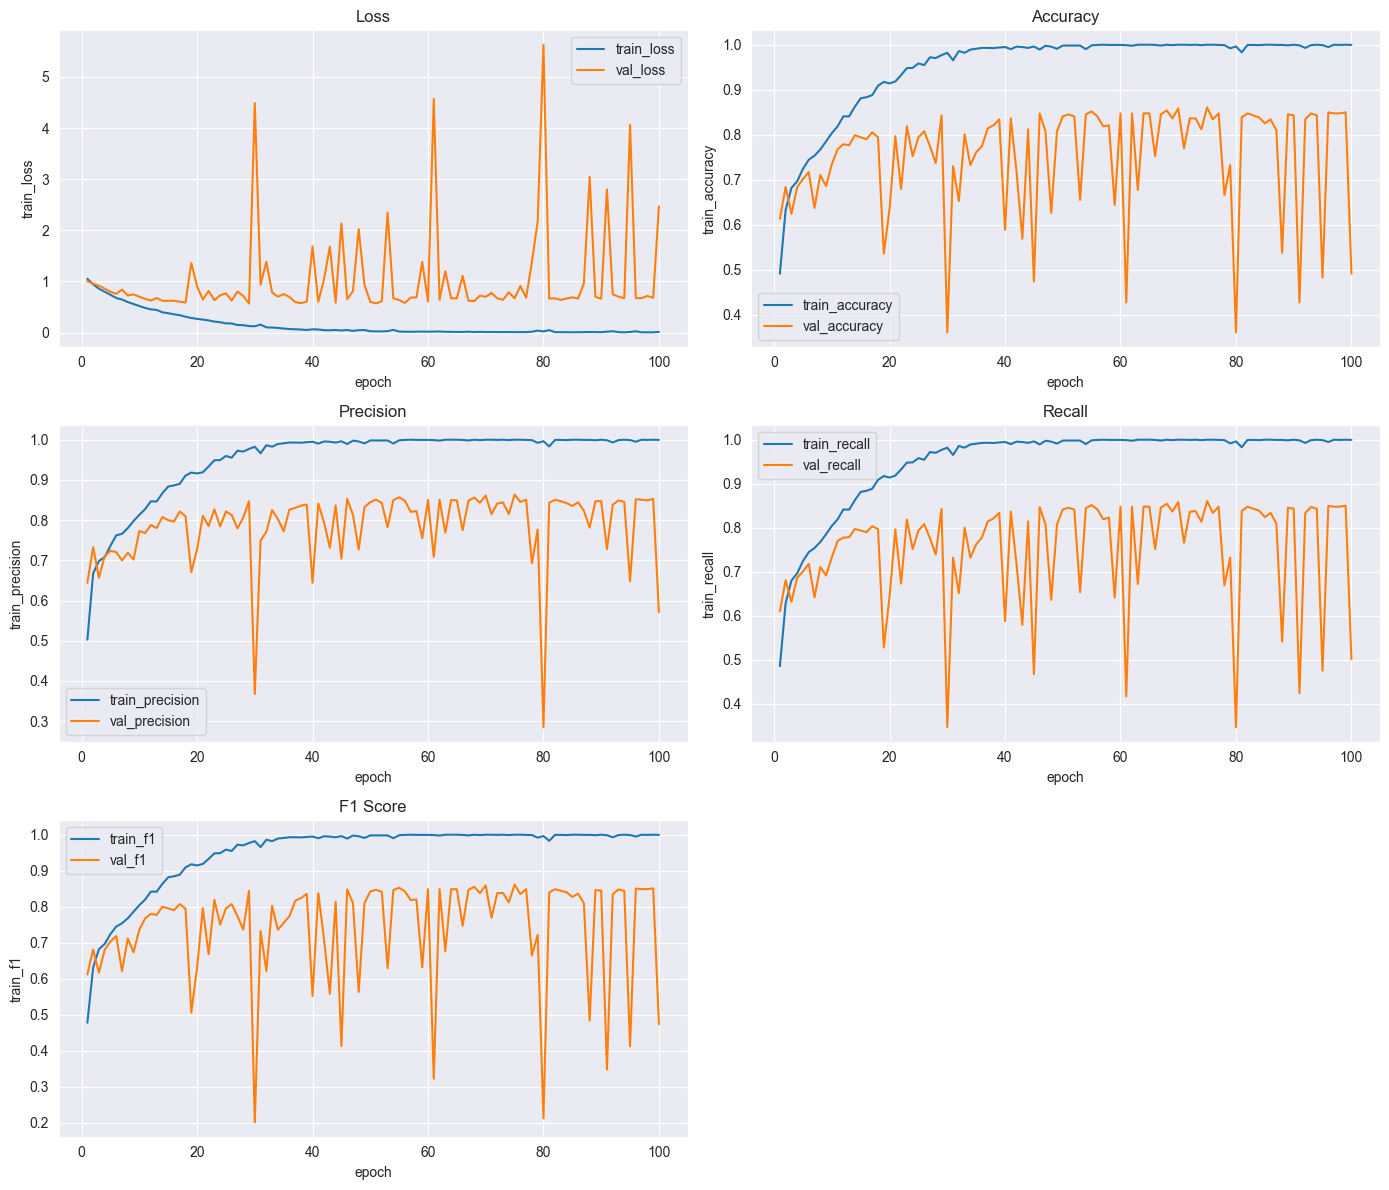

In [ ]:
df = plot_training_metrics(history)
df.to_csv("../experiments/resources/experiment3/tables/training_metrics.csv", index=False)

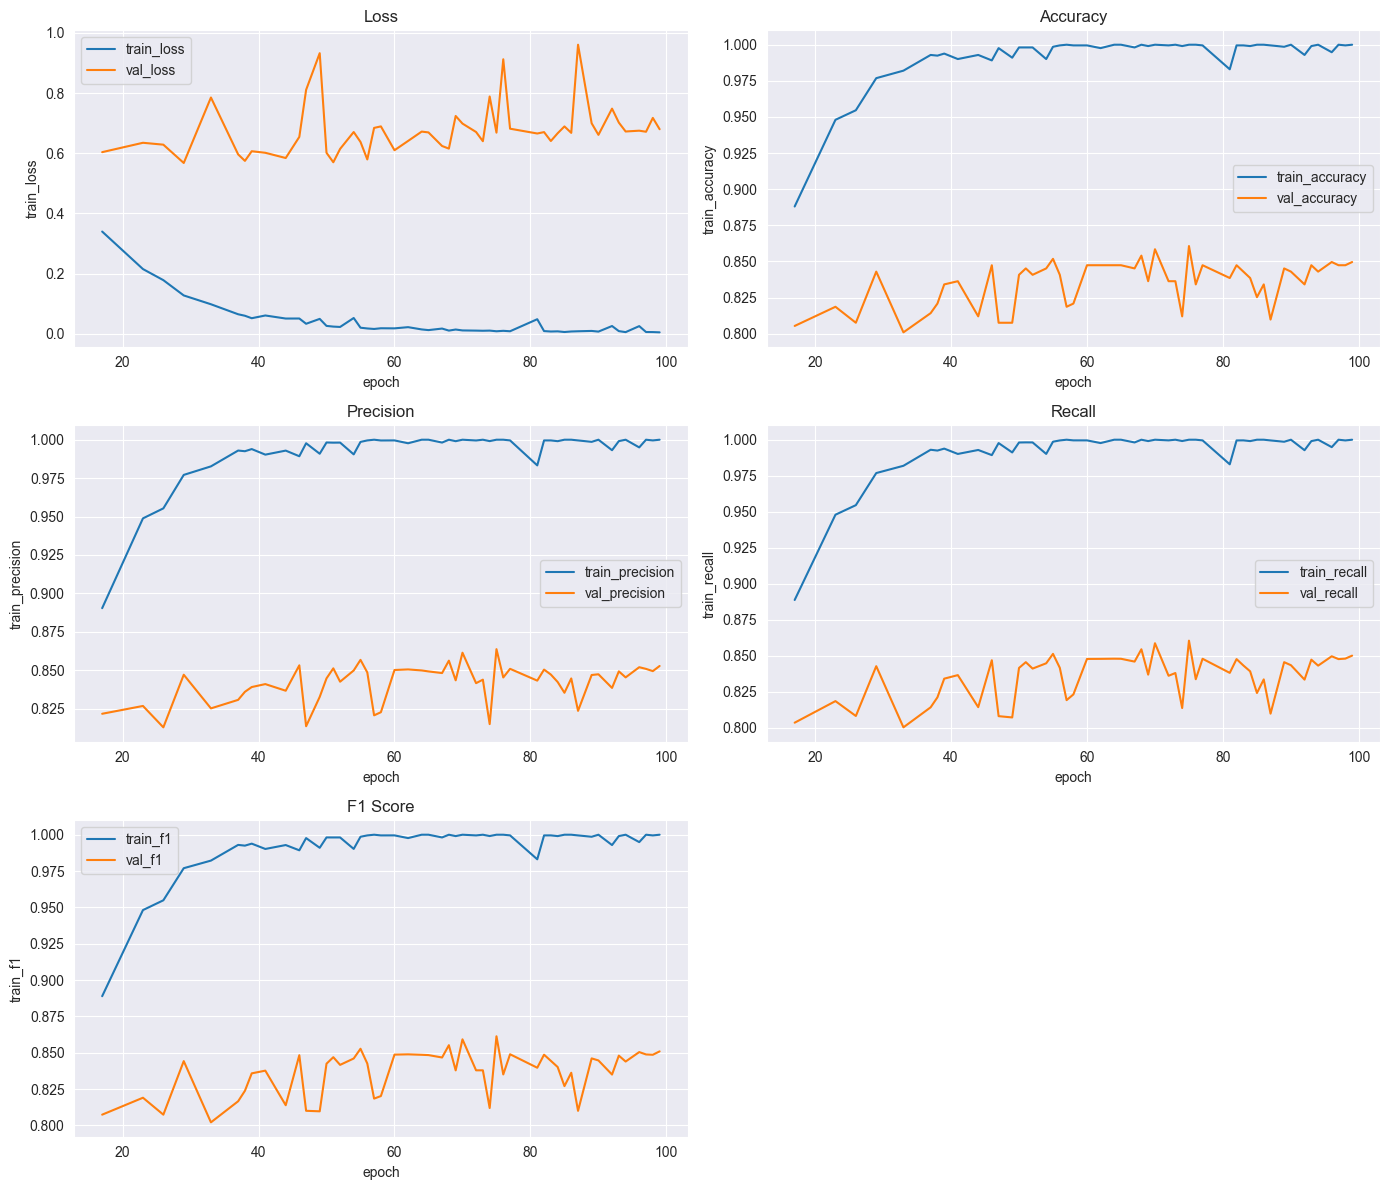

In [17]:
filtered_df = df[
    (df["val_accuracy"] >= 0.8) &
    (df["val_f1"] >= 0.8)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

### Training/Validation Trend (100 epochs)
* The model shows very strong learning capability during the early training phase. From epoch 1 to around epoch 18, training and validation performance improve consistently, with training accuracy increasing from approximately 49% to 91% and validation accuracy reaching around 80%.
* Between epochs 20–40, the model continues improving on the training set, reaching above 99% training accuracy, but validation performance becomes unstable. Several epochs show sudden validation loss spikes (for example epochs 30, 32, 40, and 43), indicating sensitivity to the validation data and possible overfitting behaviour.
* After approximately epoch 45, training metrics become extremely high, with accuracy, precision, recall, and F1 frequently above 99%. However, this improvement does not translate proportionally to validation performance. This indicates that the model is increasingly memorizing training patterns rather than improving generalization.
* From epoch 57 onward, multiple epochs reach 1.00 training accuracy, precision, recall, and F1, which is a strong indication of overfitting. These epochs were excluded from best model selection according to the given criteria.
* Validation performance remains relatively stable but fluctuates throughout the later epochs. The best validation region occurs mainly between epochs 46–75, where validation F1 stays around 0.84–0.86.
* The validation loss does not consistently decrease after the middle training phase. Large sudden increases in validation loss (epochs 61, 80, 88, 91, 95, and 100) suggest unstable generalization and possible over-confidence in predictions.
* The model achieves its best balance before complete training saturation, where training performance is high but not perfectly memorized, and validation metrics remain strong.

The training process shows rapid convergence, with the model learning meaningful patterns during the first 40 epochs and achieving very high training performance. However, after this point, training metrics continue improving while validation performance stops improving consistently, indicating increasing overfitting. The validation results suggest that the model generalizes best during the middle-to-late training stage rather than at the final epochs. The ideal checkpoint should therefore prioritize strong validation performance while avoiding epochs where training metrics reach exactly 1.00.

<b>Best Epoch 55</b>

<b>Loss</b>
* Train Loss = 0.02038
* Valid Loss = 0.63784

<b>Training Metrics</b>
* Train Accuracy = 0.99858
* Train Precison = 0.99858
* Train Recall = 0.99863
* Train F1 = 0.99860

<b>Validation Accuracy</b>
* Validation Accuracy = 0.85177
* Validation Precision = 0.85669
* Validation Recall = 0.85123
* Validation F1 = 0.85275

Here, the `Epoch 55` is selected dispite `Epoch 75` has the higher val metrics. It's because the Epoch 78 has `1.00` training Metrics which represents a serious overfitting.

## Use Tester Module to Test Model

Load Model with State Dict

In [18]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

# Loops for testing
for i in range(100):
    test_model = copy.deepcopy(model)

    checkpoint = torch.load(
        f"../models/experiment3/model_epoch_{i+1}.pt",
        map_location="cuda"
    )

    test_model.load_state_dict(checkpoint["model"])

    tester = Tester(
        test_model,
        test_loader,
        3,
        torch.nn.CrossEntropyLoss(),
        "cuda"
    )

    result = tester.test(return_predictions=True)

    test_scores.append(result)


### Save Test Metrics

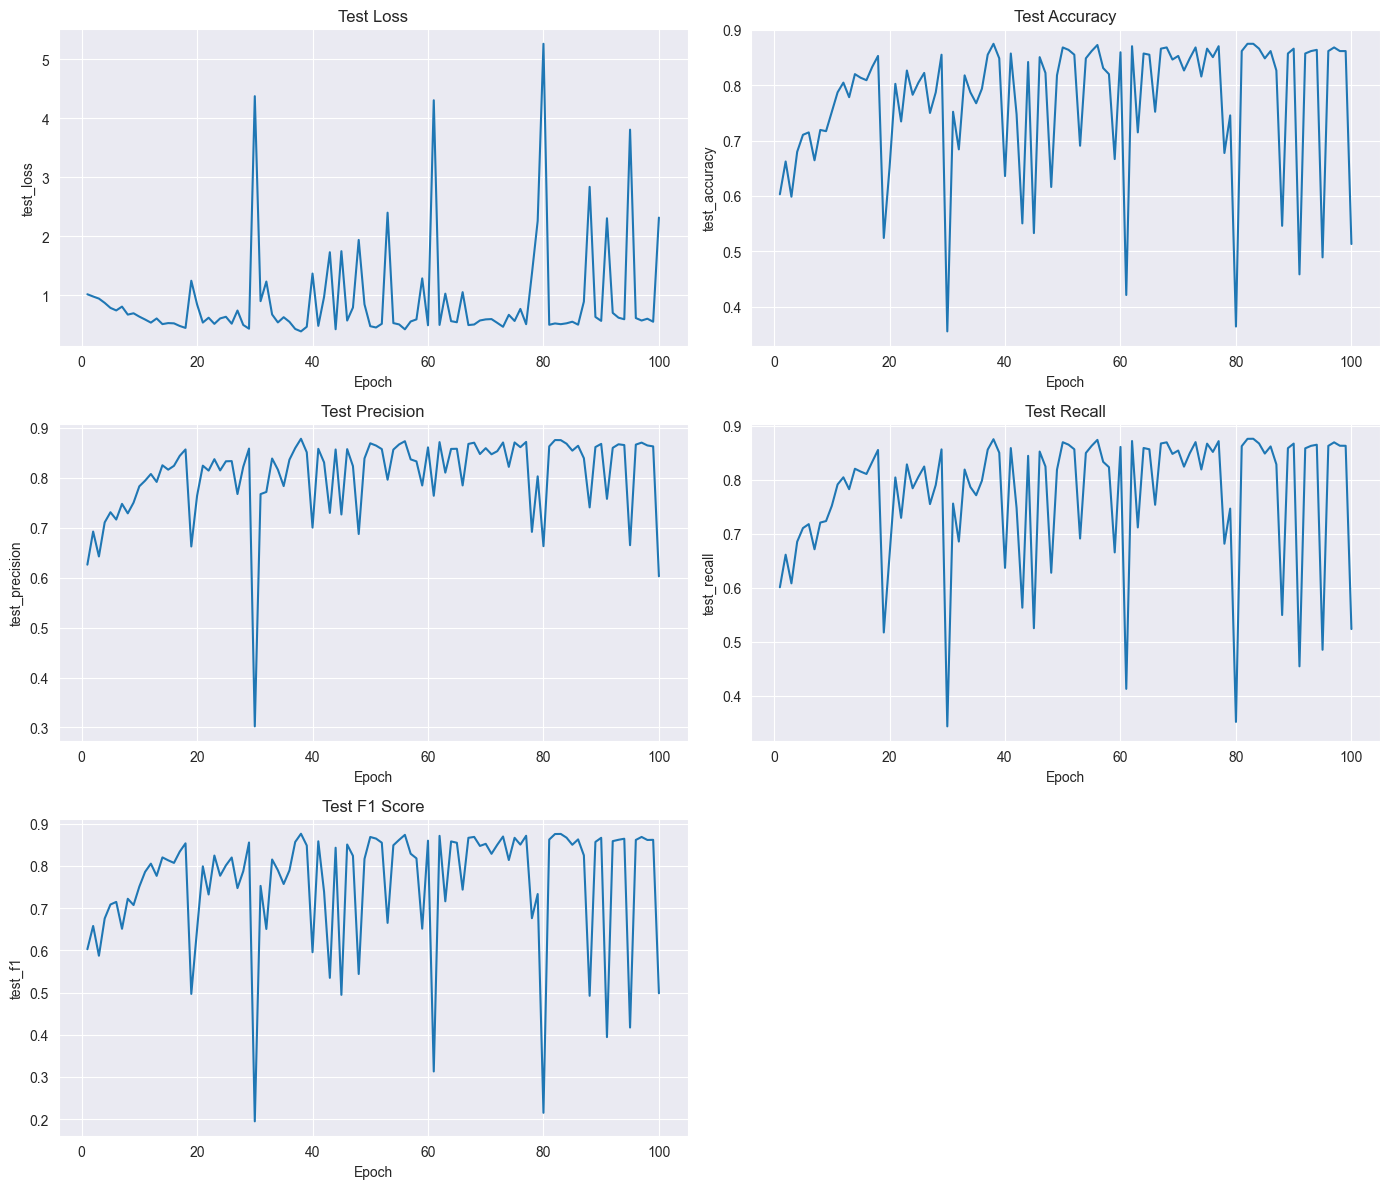

In [ ]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment3/tables/test_metrics.csv", index=False)

### Test Performance Trend (100 epochs)
* Test performance improves quickly during the first 20 epochs, showing effective initial learning and feature extraction.
* From around epoch 37 onward, the model achieves stable high test performance, with accuracy mostly above 84% and F1 above 0.84.
* The best generalization occurs in the middle training stage, where test metrics remain consistently strong.
* Several sudden performance drops appear at epochs 30, 61, 80, 91, 95, and 100, indicating unstable model behaviour at those checkpoints.
* Later epochs do not provide consistent improvement, showing that additional training does not significantly increase test performance.
* Overall, the model reaches its strongest test capability before the final epochs, with later training mainly causing fluctuations.

The test results indicate that the model learns useful patterns early and achieves strong generalization after sufficient training. The performance stabilizes around the middle epochs, while later epochs show instability with occasional severe metric drops. The best checkpoint should therefore be selected from the stable high-performing region rather than the final training stage.

<b>Best Epoch 38</b>

* Loss = 0.38508
* Accuracy = 0.8750
* Precision = 0.8782
* Recall = 0.8755
* F1-Score = 0.8763